
> **Dataset**: place your data as `dataset/train/<class_name>/...` and `dataset/test/<class_name>/...` before running the training cells.


In [1]:
# !pip install tensorflow opencv-python numpy pandas matplotlib scikit-learn Pillow


In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

%matplotlib inline


In [3]:
print("Current working directory:", os.getcwd())
print("Working directory after check:", os.getcwd())


Current working directory: C:\Users\HP\smartfashion
Working directory after check: C:\Users\HP\smartfashion


In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15
MODEL_PATH = "models/fashion_cnn.keras"
CLASS_NAMES_PATH = "models/class_names.json"
DATASET_DIR = "dataset"
SIMILAR_DIR = "dataset/reference"
CONFIDENCE_THRESHOLD = 0.50

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [5]:
COLOR_NAMES = {
    "Black": (30, 30, 30),
    "White": (225, 225, 225),
    "Gray": (128, 128, 128),
    "Red": (200, 40, 40),
    "Green": (40, 150, 70),
    "Blue": (50, 90, 190),
    "Yellow": (220, 190, 40),
    "Orange": (230, 120, 40),
    "Pink": (220, 100, 150),
    "Purple": (130, 70, 160),
    "Brown": (120, 75, 40),
    "Navy": (35, 50, 100)
}

def load_cv_image_from_path(path):
    """Load an image from disk as a BGR OpenCV array (replaces the Streamlit file-uploader version)."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image at: {path}")
    return img

def dominant_color(image_bgr):
    img = cv2.resize(image_bgr, (80, 80))
    data = np.float32(img.reshape((-1, 3)))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centers = cv2.kmeans(
        data, 4, None, criteria, 5, cv2.KMEANS_PP_CENTERS
    )
    counts = np.bincount(labels.flatten())
    bgr = centers[np.argmax(counts)]
    rgb = bgr[::-1]

    best_name = min(
        COLOR_NAMES,
        key=lambda name: np.linalg.norm(rgb - np.array(COLOR_NAMES[name]))
    )
    return best_name, tuple(int(x) for x in rgb)

def image_quality(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    brightness = float(np.mean(gray))
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    if sharpness < 40:
        sharp_status = "Low sharpness"
    elif sharpness < 120:
        sharp_status = "Medium sharpness"
    else:
        sharp_status = "Good sharpness"

    if brightness < 55:
        light_status = "Too dark"
    elif brightness > 205:
        light_status = "Too bright"
    else:
        light_status = "Good lighting"

    return {
        "brightness": round(brightness, 2),
        "sharpness": round(sharpness, 2),
        "sharpness_status": sharp_status,
        "lighting_status": light_status
    }

def normalize_text(x):
    return x.lower().replace("_", " ").replace("-", " ").strip()

def recommend(category, color, occasion="Casual"):
    c = normalize_text(category)
    col = color.lower()
    occ = occasion.lower()

    if "t shirt" in c or "tshirt" in c or "tee" in c:
        bottoms = "Blue jeans" if col in ["black", "white", "red"] else "Black jeans"
        shoes = "White sneakers"
    elif "shirt" in c:
        if "formal" in occ or "office" in occ:
            bottoms = "Black formal trousers"
            shoes = "Formal shoes"
        else:
            bottoms = "Blue jeans"
            shoes = "White sneakers"
    elif "trouser" in c or "pants" in c:
        bottoms = "Plain white/black T-shirt"
        shoes = "Sneakers or loafers"
    elif "dress" in c:
        bottoms = "Minimal accessories"
        shoes = "Heels or clean sneakers"
    elif "shoe" in c or "sneaker" in c:
        bottoms = "Slim-fit jeans"
        shoes = "The detected footwear"
    elif "jacket" in c or "coat" in c or "hoodie" in c:
        bottoms = "Jeans or neutral trousers"
        shoes = "Sneakers or boots"
    else:
        bottoms = "Neutral-colored jeans/trousers"
        shoes = "Clean sneakers"

    tips = [
        "Prefer neutral colors when you want an easy combination.",
        "Avoid combining too many strong colors in one outfit.",
        "Match the formality of footwear with the occasion."
    ]

    if occ in ["office", "formal"]:
        tips.append("Keep the outfit simple and use minimal accessories.")
    elif occ in ["party", "wedding"]:
        tips.append("Use one statement item and keep the remaining pieces balanced.")
    elif occ == "college":
        tips.append("Comfortable sneakers and simple layering work well for college.")

    return {
        "bottom": bottoms,
        "shoes": shoes,
        "tips": tips
    }

def occasion_advice(category):
    c = normalize_text(category)
    if "shirt" in c or "trouser" in c:
        return ["Office", "College", "Casual", "Party"]
    if "dress" in c:
        return ["Party", "Wedding", "Casual", "College"]
    if "shoe" in c or "sneaker" in c:
        return ["College", "Casual", "Sports", "Party"]
    if "jacket" in c or "coat" in c:
        return ["College", "Casual", "Travel", "Party"]
    return ["College", "Casual", "Party", "Travel"]

def similarity_score(img1_bgr, img2_bgr):
    a = cv2.resize(img1_bgr, (32, 32)).astype(np.float32)
    b = cv2.resize(img2_bgr, (32, 32)).astype(np.float32)
    a = a / 255.0
    b = b / 255.0
    mse = np.mean((a - b) ** 2)
    return 1.0 / (1.0 + mse)

def find_similar(query_bgr, reference_dir, limit=5):
    results = []
    if not os.path.isdir(reference_dir):
        return results

    for root, _, names in os.walk(reference_dir):
        for name in names:
            if not name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                continue
            path = os.path.join(root, name)
            img = cv2.imread(path)
            if img is None:
                continue
            score = similarity_score(query_bgr, img)
            results.append((score, path))

    results.sort(reverse=True)
    return results[:limit]




**Dataset used:** [Clothing dataset (small)](https://github.com/alexeygrigorev/clothing-dataset-small) by Alexey Grigorev — free, CC0 license.
It has ~10 classes (dress, shirt, t-shirt, pants, shoes, outwear, shorts, skirt, longsleeve, hat) already split into `train/`, `test/`, and `validation/` folders — a direct match for this project's structure.



In [6]:
import subprocess, shutil, zipfile, urllib.request

def _download_clothing_dataset():
    os.makedirs(DATASET_DIR, exist_ok=True)
    tmp_dir = "_clothing_dataset_tmp"
    if os.path.isdir(tmp_dir):
        shutil.rmtree(tmp_dir)

    extracted_root = None

    
    try:
        zip_url = "https://github.com/alexeygrigorev/clothing-dataset-small/archive/refs/heads/master.zip"
        zip_path = "_clothing_dataset.zip"
        print("Downloading dataset zip...")
        urllib.request.urlretrieve(zip_url, zip_path)

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(tmp_dir)
        os.remove(zip_path)

        # The zip extracts into a subfolder like clothing-dataset-small-master
        candidates = [d for d in os.listdir(tmp_dir) if os.path.isdir(os.path.join(tmp_dir, d))]
        if candidates:
            extracted_root = os.path.join(tmp_dir, candidates[0])
    except Exception as e:
        print("ZIP download failed:", e)

   
    if extracted_root is None and shutil.which("git") is not None:
        try:
            if os.path.isdir(tmp_dir):
                shutil.rmtree(tmp_dir)
            print("Falling back to git clone...")
            subprocess.run(
                ["git", "clone", "--depth", "1",
                 "https://github.com/alexeygrigorev/clothing-dataset-small.git", tmp_dir],
                check=True
            )
            extracted_root = tmp_dir
        except Exception as e:
            print("git clone also failed:", e)

    if extracted_root is None:
        print("Automatic download failed. Please download manually:")
        print("  https://github.com/alexeygrigorev/clothing-dataset-small")
        print("Click 'Code' > 'Download ZIP', extract it, and copy its")
        print("train/, test/, validation/ folders into the 'dataset/' folder next to this notebook.")
        return False

   
    moved_any = False
    for split in ["train", "test", "validation"]:
        src = os.path.join(extracted_root, split)
        dst = os.path.join(DATASET_DIR, split)
        if os.path.isdir(src):
            if os.path.isdir(dst):
                shutil.rmtree(dst)
            shutil.move(src, dst)
            moved_any = True

    shutil.rmtree(tmp_dir, ignore_errors=True)
    return moved_any


if not os.path.isdir(os.path.join(DATASET_DIR, "train")):
    ok = _download_clothing_dataset()
    if ok:
        print("Dataset ready at:", os.path.abspath(DATASET_DIR))
    else:
        print("Dataset was NOT set up automatically — see instructions above.")
else:
    print("dataset/train already exists — skipping download.")


for split in ["train", "test"]:
    p = os.path.join(DATASET_DIR, split)
    if os.path.isdir(p):
        classes = sorted(os.listdir(p))
        print(f"{split}: {classes}")
    else:
        print(f"{split}: NOT FOUND at {os.path.abspath(p)}")


dataset/train already exists — skipping download.
train: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
test: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']


### Load the dataset into TensorFlow

In [7]:
train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    shuffle=True, seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

print("Classes found:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


Found 3068 files belonging to 10 classes.
Found 373 files belonging to 10 classes.
Classes found: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']


#Build & Train the CNN Model


In [8]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,486,986 (9.49 MB)

 Trainable params: 2,486,986 (9.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor="val_accuracy", save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 89s 857ms/step - accuracy: 0.2904 - loss: 2.0681 - val_accuracy: 0.2949 - val_loss: 1.9984
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 135s 792ms/step - accuracy: 0.4619 - loss: 1.6131 - val_accuracy: 0.5362 - val_loss: 1.4494
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 796ms/step - accuracy: 0.5691 - loss: 1.3069 - val_accuracy: 0.5684 - val_loss: 1.3009
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 88s 864ms/step - accuracy: 0.6167 - loss: 1.1300 - val_accuracy: 0.6193 - val_loss: 1.0989
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 751s 8s/step - accuracy: 0.6819 - loss: 0.9621 - val_accuracy: 0.5979 - val_loss: 1.1336
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7154 - loss: 0.8287 - val_accuracy: 0.6461 - val_loss: 1.0146
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.7461 - loss: 0.7316 - val_accuracy: 0.6327 - val_loss: 1.1523
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7728 - loss: 0.6421 - val_accuracy: 0

## 6. Training Curves

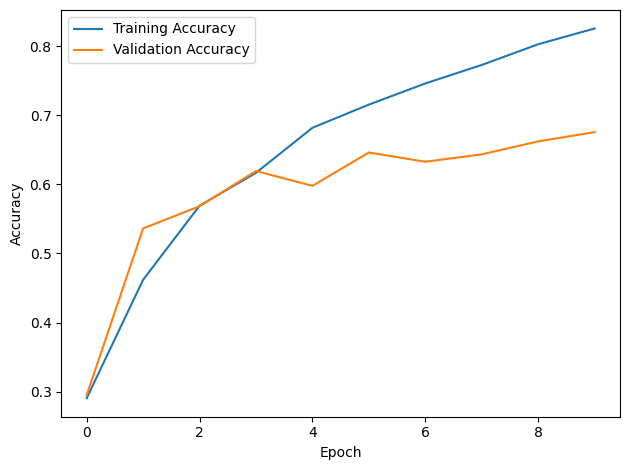

In [19]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/accuracy.png")

plt.show()


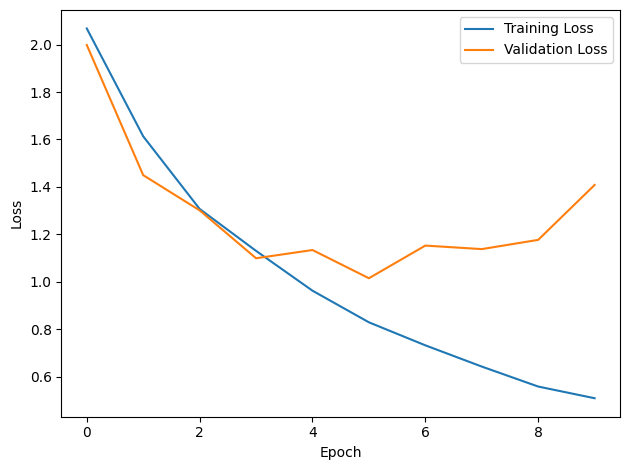

In [20]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/loss.png")
plt.show()


## 7. Evaluation — Classification Report & Confusion Matrix

In [21]:
y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
np.savetxt("outputs/confusion_matrix.csv", cm, delimiter=",", fmt="%d")
print("Confusion Matrix:")
print(cm)
print("Model saved to:", MODEL_PATH)


Classification Report:
              precision    recall  f1-score   support

       dress       0.73      0.69      0.71        16
         hat       0.00      0.00      0.00        12
  longsleeve       0.56      0.49      0.52        72
     outwear       0.82      0.37      0.51        38
       pants       0.93      0.95      0.94        42
       shirt       0.34      0.77      0.48        26
       shoes       0.86      0.68      0.76        73
      shorts       0.51      0.90      0.65        30
       skirt       0.67      0.33      0.44        12
     t-shirt       0.67      0.77      0.71        52

    accuracy                           0.65       373
   macro avg       0.61      0.60      0.57       373
weighted avg       0.68      0.65      0.64       373

Confusion Matrix:
[[11  0  0  1  0  1  0  0  0  3]
 [ 2  0  1  0  0  2  3  0  0  4]
 [ 0  0 35  1  0 23  0  2  0 11]
 [ 0  0 14 14  1  7  0  1  1  0]
 [ 0  0  0  0 40  0  1  1  0  0]
 [ 0  0  4  0  0 20  0  0  0  2]
 [

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


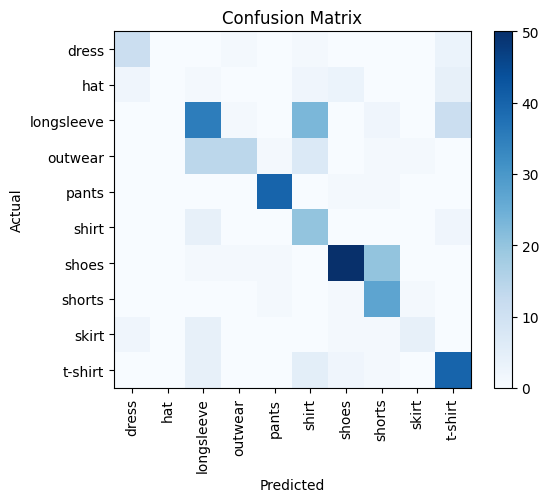

In [17]:
# Optional: visualize the confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png")
plt.show()


In [16]:
pip install streamlit tensorflow numpy opencv-python pillow

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
